# Notebook 09 — Glycosylation / Quality Coupling Simulation

## Goal

Notebook09 extends the CLD simulation from productivity and process optimization into product quality.

Earlier notebooks asked:

> Which clone should advance?

Notebook07 and 07b asked:

> Which clone × process combination should advance?

Notebook09 asks:

> Does the selected clone × process combination also maintain acceptable product quality?

This notebook focuses on simulated glycosylation and quality attributes:

- glycan maturity
- galactosylation
- sialylation
- high-mannose retention risk
- aggregation propensity
- product quality consistency

## Why this matters

A clone with high productivity is not always a good manufacturing clone.

A strong production clone can still fail because of:

- poor glycosylation profile
- high-mannose risk
- aggregation risk
- unstable product quality
- process-sensitive quality drift

Notebook09 tests whether clone × process recommendations remain acceptable after adding product quality constraints.

In [1]:
# --------------------------------------------------
# Section 1 — Imports and load inputs
# --------------------------------------------------

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display


def find_project_root(start=None):
    if start is None:
        start = Path.cwd().resolve()
    start = Path(start).resolve()

    for p in [start, *start.parents]:
        if (p / "data" / "synthetic").exists():
            return p

    raise FileNotFoundError("Could not find project root containing data/synthetic")


ROOT = find_project_root()

scenario = "legacy"
n_clones = 5000

PRED_PATH = ROOT / "data" / "synthetic" / "processed" / f"predictions_03b_qp_{n_clones}_{scenario}.csv"
LATENT_PATH = ROOT / "data" / "synthetic" / "raw" / f"clone_latent_truths_{n_clones}_{scenario}.csv"
ACTION07_PATH = ROOT / "reports" / f"notebook07_action_recommendations_{n_clones}_{scenario}.csv"
RESCUE07B_PATH = ROOT / "data" / "synthetic" / "process" / f"notebook07b_rescue_transition_table_{n_clones}_{scenario}.csv"

print("ROOT:", ROOT)
print("PRED_PATH:", PRED_PATH)
print("LATENT_PATH:", LATENT_PATH)
print("ACTION07_PATH:", ACTION07_PATH)
print("RESCUE07B_PATH:", RESCUE07B_PATH)

pred = pd.read_csv(PRED_PATH)
latent = pd.read_csv(LATENT_PATH)

print("pred:", pred.shape)
print("latent:", latent.shape)

display(pred.head())
display(latent.head())

ROOT: /Users/sang/CLD_ML_PIPELINE
PRED_PATH: /Users/sang/CLD_ML_PIPELINE/data/synthetic/processed/predictions_03b_qp_5000_legacy.csv
LATENT_PATH: /Users/sang/CLD_ML_PIPELINE/data/synthetic/raw/clone_latent_truths_5000_legacy.csv
ACTION07_PATH: /Users/sang/CLD_ML_PIPELINE/reports/notebook07_action_recommendations_5000_legacy.csv
RESCUE07B_PATH: /Users/sang/CLD_ML_PIPELINE/data/synthetic/process/notebook07b_rescue_transition_table_5000_legacy.csv
pred: (1000, 20)
latent: (5000, 33)


,clone_id,pred_qp_drop,pred_late_qp,pred_late_agg,pred_stable_prob,pred_stable_label,true_qp_drop,true_late_qp,true_late_agg,true_stable_label,pred_super_prob,pred_aggr_prob,true_is_aggressive,rescue_upside_qp,rescue_stability_band,rescue_quality_band,rescue_aggressive_penalty,rescue_not_already_pass,pred_rescue_score,pred_rescue_label
0,CLONE_1502,0.381373,2.711177e-08,9.583127,0.370940,0,0.111023,4.176362e-08,12.566994,1,0.000000,0.024314,0,0.000518,0.895422,0.803068,0.974885,0.486344,0.598822,1
1,CLONE_2587,0.489493,6.445184e-08,3.127400,0.169707,0,0.691891,3.691256e-08,0.918511,0,0.000000,0.001179,0,0.007290,0.535023,0.000000,0.998782,0.769478,0.264869,0
2,CLONE_2654,0.362087,3.071979e-08,7.313653,0.492969,0,0.009193,4.002863e-08,6.558486,1,0.004355,0.014202,0,0.001172,0.959708,0.661044,0.985331,0.314649,0.571715,0
3,CLONE_1056,0.353752,6.793292e-08,6.868662,0.478848,0,0.708930,3.026369e-08,7.990409,0,0.004891,0.001310,0,0.007922,0.987492,0.533903,0.998647,0.334518,0.549744,0
4,CLONE_0706,0.616517,1.729449e-07,8.278383,0.036653,0,0.740570,1.029717e-07,7.441547,0,0.012486,0.072412,0,0.026969,0.111609,0.936681,0.925203,0.956685,0.397218,0


,clone_id,productivity,stability,quality_potential,G_platform,platform_group,CN_true,CN_obs,k_decay_i,is_super,...,temperature_shift_responsiveness,feed_responsiveness,secretion_burden_index,process_risk_sensitivity,glycan_maturity,galactosylation_level,sialylation_capacity,mannose_retention_risk,aggregation_propensity,product_quality_consistency
0,CLONE_0001,124.997447,0.538616,0.744077,0.439489,0,4,4,0.046569,0,...,0.796684,0.673384,0.641011,0.665561,0.510380,0.474859,0.712412,0.351708,0.517492,0.927489
1,CLONE_0002,33.211918,0.589661,0.690279,0.266919,0,2,2,0.041989,0,...,0.363707,0.720059,0.135232,0.512033,0.726037,0.873543,0.769229,0.384423,0.422744,0.776842
2,CLONE_0003,202.192272,0.589914,0.931177,0.518985,0,5,5,0.070121,0,...,0.797512,0.567776,0.835971,0.563885,0.677784,0.641572,0.835368,0.246703,0.399638,0.598556
3,CLONE_0004,50.943834,0.594953,0.956343,0.638136,0,4,4,0.041947,0,...,0.214300,0.573670,0.484414,0.449087,0.701004,0.885609,0.909993,0.305757,0.268689,0.751828
4,CLONE_0005,126.141664,0.634075,0.897775,0.805367,0,6,6,0.052817,0,...,0.459047,0.611617,0.768044,0.641787,0.879994,0.682306,0.706165,0.113121,0.544114,0.883391


## Section 2 — Merge prediction output with glycosylation latent biology

This section combines:

1. Notebook03 prediction outputs  
2. Generator-derived glycosylation / product-quality latent variables

The glycosylation latent variables are hidden biological tendencies.

They are not used for Notebook03 ML prediction.

They are used here to simulate downstream product quality behavior.

In [2]:
# --------------------------------------------------
# Section 2 — Merge prediction output with glyco latents
# --------------------------------------------------

glyco_cols = [
    "clone_id",
    "glycan_maturity",
    "galactosylation_level",
    "sialylation_capacity",
    "mannose_retention_risk",
    "aggregation_propensity",
    "product_quality_consistency",
    "nutrient_utilization_efficiency",
    "stress_adaptation_capacity",
    "perfusion_rescue_potential",
    "temperature_shift_responsiveness",
    "feed_responsiveness",
    "secretion_burden_index",
    "process_risk_sensitivity",
    "is_aggressive",
    "is_super",
]

missing_glyco = [c for c in glyco_cols if c not in latent.columns]
print("Missing glyco/process latent columns:", missing_glyco)
assert len(missing_glyco) == 0, f"Missing columns: {missing_glyco}"

df = pred.merge(
    latent[glyco_cols],
    on="clone_id",
    how="left",
)

required_cols = [
    "clone_id",
    "pred_late_qp",
    "pred_qp_drop",
    "pred_late_agg",
    "pred_stable_prob",
    "pred_rescue_score",
    "pred_rescue_label",
    "glycan_maturity",
    "galactosylation_level",
    "sialylation_capacity",
    "mannose_retention_risk",
    "aggregation_propensity",
    "product_quality_consistency",
]

missing = [c for c in required_cols if c not in df.columns]
print("Missing required columns:", missing)
assert len(missing) == 0, f"Missing required columns: {missing}"

print("merged:", df.shape)
display(df.head())
display(df[glyco_cols[1:]].describe())

Missing glyco/process latent columns: []
Missing required columns: []
merged: (1000, 35)


,clone_id,pred_qp_drop,pred_late_qp,pred_late_agg,pred_stable_prob,pred_stable_label,true_qp_drop,true_late_qp,true_late_agg,true_stable_label,...,product_quality_consistency,nutrient_utilization_efficiency,stress_adaptation_capacity,perfusion_rescue_potential,temperature_shift_responsiveness,feed_responsiveness,secretion_burden_index,process_risk_sensitivity,is_aggressive,is_super
0,CLONE_1502,0.381373,2.711177e-08,9.583127,0.370940,0,0.111023,4.176362e-08,12.566994,1,...,1.000000,0.714663,0.643065,0.450092,0.287103,0.453787,0.009955,0.265650,0,0
1,CLONE_2587,0.489493,6.445184e-08,3.127400,0.169707,0,0.691891,3.691256e-08,0.918511,0,...,0.619538,0.741458,0.733727,0.260307,0.588883,0.623808,0.461429,0.340751,0,0
2,CLONE_2654,0.362087,3.071979e-08,7.313653,0.492969,0,0.009193,4.002863e-08,6.558486,1,...,0.764122,0.427308,0.512669,0.470485,0.238474,0.373872,0.227617,0.534961,0,0
3,CLONE_1056,0.353752,6.793292e-08,6.868662,0.478848,0,0.708930,3.026369e-08,7.990409,0,...,0.907431,0.551334,0.527079,0.447419,0.543270,0.735064,0.354122,0.540352,0,0
4,CLONE_0706,0.616517,1.729449e-07,8.278383,0.036653,0,0.740570,1.029717e-07,7.441547,0,...,0.729800,0.417567,0.482788,0.355846,0.673496,0.660623,0.676830,0.496857,0,0


,glycan_maturity,galactosylation_level,sialylation_capacity,mannose_retention_risk,aggregation_propensity,product_quality_consistency,nutrient_utilization_efficiency,stress_adaptation_capacity,perfusion_rescue_potential,temperature_shift_responsiveness,feed_responsiveness,secretion_burden_index,process_risk_sensitivity,is_aggressive,is_super
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.745794,0.646106,0.594542,0.319043,0.465217,0.688259,0.608991,0.642516,0.438471,0.499358,0.491757,0.454408,0.505118,0.039000,0.014000
std,0.180416,0.195425,0.198829,0.195922,0.216444,0.195184,0.136374,0.138156,0.141638,0.134336,0.130223,0.221333,0.153076,0.193692,0.117549
min,0.101207,0.049513,0.097361,0.000000,0.000000,0.000000,0.157823,0.000000,0.009806,0.139244,0.029765,0.000000,0.000000,0.000000,0.000000
25%,0.638254,0.508567,0.445928,0.172009,0.301930,0.549951,0.525684,0.558239,0.335844,0.410332,0.399839,0.293117,0.397109,0.000000,0.000000
50%,0.774058,0.643497,0.590456,0.301281,0.455010,0.698692,0.613092,0.642345,0.443031,0.491186,0.495391,0.456173,0.498499,0.000000,0.000000
75%,0.879916,0.787073,0.739359,0.442799,0.617080,0.837199,0.699970,0.732393,0.530205,0.594815,0.577970,0.618664,0.609713,0.000000,0.000000
max,1.000000,1.000000,1.000000,0.985368,1.000000,1.000000,1.000000,1.000000,0.901515,1.000000,0.883416,1.000000,1.000000,1.000000,1.000000


## Section 3 — Baseline product-quality score

This section creates a baseline quality score before process-specific quality simulation.

Higher quality score means:

- higher glycan maturity
- higher galactosylation
- higher sialylation capacity
- lower high-mannose risk
- lower aggregation propensity
- higher product quality consistency

This score is not a real release specification.

It is a simulated product-quality index for ranking and comparison.

In [3]:
# --------------------------------------------------
# Section 3 — Baseline product-quality score
# --------------------------------------------------

def z(s):
    s = pd.Series(s).astype(float)
    return (s - s.mean()) / (s.std() + 1e-12)

def z_from_ref(x, ref):
    ref = pd.Series(ref).astype(float)
    return (x - ref.mean()) / (ref.std() + 1e-12)

df["baseline_quality_score"] = (
    0.25 * z(df["glycan_maturity"])
    + 0.20 * z(df["galactosylation_level"])
    + 0.10 * z(df["sialylation_capacity"])
    - 0.20 * z(df["mannose_retention_risk"])
    - 0.15 * z(df["aggregation_propensity"])
    + 0.10 * z(df["product_quality_consistency"])
)

df["baseline_quality_rank"] = df["baseline_quality_score"].rank(
    ascending=False,
    method="dense"
)

print("=== Baseline product-quality score summary ===")
display(df["baseline_quality_score"].describe())

display(
    df[
        [
            "clone_id",
            "baseline_quality_score",
            "baseline_quality_rank",
            "glycan_maturity",
            "galactosylation_level",
            "sialylation_capacity",
            "mannose_retention_risk",
            "aggregation_propensity",
            "product_quality_consistency",
            "pred_late_qp",
            "pred_qp_drop",
            "pred_late_agg",
        ]
    ]
    .sort_values("baseline_quality_score", ascending=False)
    .head(15)
)

=== Baseline product-quality score summary ===


count    1.000000e+03
mean     2.486900e-17
std      4.895574e-01
min     -1.748736e+00
25%     -3.425966e-01
50%      3.531265e-02
75%      3.542993e-01
max      1.330006e+00
Name: baseline_quality_score, dtype: float64

,clone_id,baseline_quality_score,baseline_quality_rank,glycan_maturity,galactosylation_level,sialylation_capacity,mannose_retention_risk,aggregation_propensity,product_quality_consistency,pred_late_qp,pred_qp_drop,pred_late_agg
926,CLONE_3895,1.330006,1.0,1.000000,0.811800,1.000000,0.000000,0.018254,0.627405,8.950082e-08,0.363346,4.486685
861,CLONE_3434,1.303040,2.0,1.000000,1.000000,0.824340,0.128169,0.267638,0.963983,9.215160e-07,0.672361,3.163844
167,CLONE_1591,1.202800,3.0,1.000000,0.904594,1.000000,0.238883,0.175064,0.881840,2.718107e-07,0.357162,4.642763
90,CLONE_4154,1.170730,4.0,1.000000,0.835291,0.911808,0.144321,0.281637,1.000000,3.751035e-08,0.368023,4.298296
806,CLONE_3099,1.135675,5.0,0.942061,1.000000,0.926375,0.091568,0.473872,0.899888,4.178476e-08,0.390522,3.808561
973,CLONE_1306,1.121420,6.0,1.000000,0.840623,0.835812,0.092476,0.348707,0.955129,2.485773e-08,0.423081,5.615982
396,CLONE_1633,1.064658,7.0,1.000000,0.639029,0.822961,0.053910,0.175315,0.948264,4.668606e-08,0.346146,4.569337
192,CLONE_3945,1.064356,8.0,0.988173,0.555404,1.000000,0.084062,0.099004,0.929764,3.178977e-08,0.403809,3.530696
854,CLONE_2522,1.063410,9.0,1.000000,1.000000,0.550511,0.000000,0.305407,0.560788,7.949363e-08,0.413741,3.533818
100,CLONE_1554,1.044824,10.0,0.882493,0.680205,0.984440,0.000000,0.244762,0.973121,5.103521e-08,0.364593,3.649782


## Section 4 — Define process effects on glycosylation and quality

Different process strategies can shift product quality attributes.

For example:

- rich media may increase productivity but also increase stress and aggregation risk
- mild temperature shift may improve stress handling and reduce aggregation risk
- perfusion-like operation may reduce waste-related quality stress
- nutrient limitation may reduce stress but can reduce productivity
- balanced feeding may improve quality consistency

These effects are conservative and simulation-based.

In [4]:
# --------------------------------------------------
# Section 4 — Define process quality effect library
# --------------------------------------------------

QUALITY_PROCESS_LIBRARY = {
    "baseline": {
        "glycan_maturity_shift": 0.00,
        "galactosylation_shift": 0.00,
        "sialylation_shift": 0.00,
        "mannose_shift": 0.00,
        "aggregation_shift": 0.00,
        "consistency_shift": 0.00,
        "quality_stress": 0.00,
    },
    "rich_media": {
        "glycan_maturity_shift": 0.01,
        "galactosylation_shift": 0.04,
        "sialylation_shift": 0.00,
        "mannose_shift": 0.02,
        "aggregation_shift": 0.04,
        "consistency_shift": -0.02,
        "quality_stress": 0.30,
    },
    "balanced_feed": {
        "glycan_maturity_shift": 0.04,
        "galactosylation_shift": 0.05,
        "sialylation_shift": 0.02,
        "mannose_shift": -0.03,
        "aggregation_shift": -0.03,
        "consistency_shift": 0.04,
        "quality_stress": 0.05,
    },
    "nutrient_limited": {
        "glycan_maturity_shift": 0.02,
        "galactosylation_shift": -0.01,
        "sialylation_shift": -0.01,
        "mannose_shift": -0.04,
        "aggregation_shift": -0.05,
        "consistency_shift": 0.03,
        "quality_stress": -0.10,
    },
    "mild_temp_shift": {
        "glycan_maturity_shift": 0.05,
        "galactosylation_shift": 0.03,
        "sialylation_shift": 0.02,
        "mannose_shift": -0.04,
        "aggregation_shift": -0.06,
        "consistency_shift": 0.05,
        "quality_stress": -0.15,
    },
    "perfusion_like": {
        "glycan_maturity_shift": 0.04,
        "galactosylation_shift": 0.02,
        "sialylation_shift": 0.01,
        "mannose_shift": -0.05,
        "aggregation_shift": -0.05,
        "consistency_shift": 0.04,
        "quality_stress": -0.12,
    },
    "stress_minimized": {
        "glycan_maturity_shift": 0.05,
        "galactosylation_shift": 0.02,
        "sialylation_shift": 0.02,
        "mannose_shift": -0.05,
        "aggregation_shift": -0.07,
        "consistency_shift": 0.06,
        "quality_stress": -0.20,
    },
    "adaptive_perfusion": {
        "glycan_maturity_shift": 0.04,
        "galactosylation_shift": 0.03,
        "sialylation_shift": 0.01,
        "mannose_shift": -0.04,
        "aggregation_shift": -0.04,
        "consistency_shift": 0.04,
        "quality_stress": -0.10,
    },
}

quality_process_table = pd.DataFrame(QUALITY_PROCESS_LIBRARY).T
display(quality_process_table)

,glycan_maturity_shift,galactosylation_shift,sialylation_shift,mannose_shift,aggregation_shift,consistency_shift,quality_stress
baseline,0.00,0.00,0.00,0.00,0.00,0.00,0.00
rich_media,0.01,0.04,0.00,0.02,0.04,-0.02,0.30
balanced_feed,0.04,0.05,0.02,-0.03,-0.03,0.04,0.05
nutrient_limited,0.02,-0.01,-0.01,-0.04,-0.05,0.03,-0.10
mild_temp_shift,0.05,0.03,0.02,-0.04,-0.06,0.05,-0.15
perfusion_like,0.04,0.02,0.01,-0.05,-0.05,0.04,-0.12
stress_minimized,0.05,0.02,0.02,-0.05,-0.07,0.06,-0.20
adaptive_perfusion,0.04,0.03,0.01,-0.04,-0.04,0.04,-0.10


## Section 5 — Simulate clone × process quality outcomes

This section expands each clone across virtual process conditions.

The quality response depends on:

- baseline glycosylation latent state
- process condition
- stress adaptation capacity
- feed responsiveness
- secretion burden
- process risk sensitivity
- product quality consistency

The same process condition can therefore improve one clone and worsen another.

In [5]:
# --------------------------------------------------
# Section 5 — Simulate clone × process quality outcomes
# --------------------------------------------------

quality_rows = []

for _, row in df.iterrows():

    for process_name, params in QUALITY_PROCESS_LIBRARY.items():

        stress_adapt = row["stress_adaptation_capacity"]
        feed_resp = row["feed_responsiveness"]
        burden = row["secretion_burden_index"]
        risk = row["process_risk_sensitivity"]
        consistency = row["product_quality_consistency"]

        # Clone-specific quality response scaling
        quality_response = (
            0.35 * stress_adapt
            + 0.20 * feed_resp
            + 0.25 * consistency
            + 0.20 * (1.0 - risk)
        )

        quality_response = np.clip(quality_response, 0.0, 1.0)

        # Stress penalty is stronger in high-risk / high-burden clones
        stress_penalty = (
            params["quality_stress"]
            * (0.5 + 0.5 * risk)
            * (0.5 + 0.5 * burden)
        )

        # Apply shifts
        process_glycan_maturity = np.clip(
            row["glycan_maturity"]
            + params["glycan_maturity_shift"] * (0.5 + quality_response)
            - max(0, stress_penalty) * 0.05,
            0,
            1,
        )

        process_galactosylation = np.clip(
            row["galactosylation_level"]
            + params["galactosylation_shift"] * (0.5 + 0.7 * feed_resp)
            - max(0, stress_penalty) * 0.04,
            0,
            1,
        )

        process_sialylation = np.clip(
            row["sialylation_capacity"]
            + params["sialylation_shift"] * (0.5 + 0.7 * stress_adapt)
            - max(0, stress_penalty) * 0.05,
            0,
            1,
        )

        process_mannose_risk = np.clip(
            row["mannose_retention_risk"]
            + params["mannose_shift"] * (0.5 + quality_response)
            + max(0, stress_penalty) * 0.06,
            0,
            1,
        )

        process_aggregation_propensity = np.clip(
            row["aggregation_propensity"]
            + params["aggregation_shift"] * (0.5 + quality_response)
            + max(0, stress_penalty) * 0.06,
            0,
            1,
        )

        process_quality_consistency = np.clip(
            row["product_quality_consistency"]
            + params["consistency_shift"] * (0.5 + quality_response)
            - max(0, stress_penalty) * 0.04,
            0,
            1,
        )

        process_quality_score = (
            0.25 * z_from_ref(process_glycan_maturity, df["glycan_maturity"])
            + 0.20 * z_from_ref(process_galactosylation, df["galactosylation_level"])
            + 0.10 * z_from_ref(process_sialylation, df["sialylation_capacity"])
            - 0.20 * z_from_ref(process_mannose_risk, df["mannose_retention_risk"])
            - 0.15 * z_from_ref(process_aggregation_propensity, df["aggregation_propensity"])
            + 0.10 * z_from_ref(process_quality_consistency, df["product_quality_consistency"])
        )

        quality_rows.append({
            "clone_id": row["clone_id"],
            "process_condition": process_name,

            "baseline_quality_score": row["baseline_quality_score"],
            "process_quality_score": process_quality_score,
            "quality_score_gain": process_quality_score - row["baseline_quality_score"],

            "glycan_maturity": row["glycan_maturity"],
            "process_glycan_maturity": process_glycan_maturity,

            "galactosylation_level": row["galactosylation_level"],
            "process_galactosylation_level": process_galactosylation,

            "sialylation_capacity": row["sialylation_capacity"],
            "process_sialylation_capacity": process_sialylation,

            "mannose_retention_risk": row["mannose_retention_risk"],
            "process_mannose_retention_risk": process_mannose_risk,

            "aggregation_propensity": row["aggregation_propensity"],
            "process_aggregation_propensity": process_aggregation_propensity,

            "product_quality_consistency": row["product_quality_consistency"],
            "process_quality_consistency": process_quality_consistency,

            "quality_response": quality_response,
            "stress_penalty": stress_penalty,

            "pred_late_qp": row["pred_late_qp"],
            "pred_qp_drop": row["pred_qp_drop"],
            "pred_late_agg": row["pred_late_agg"],
            "pred_rescue_score": row["pred_rescue_score"],
            "pred_rescue_label": row["pred_rescue_label"],

            "is_aggressive": row.get("is_aggressive", np.nan),
            "is_super": row.get("is_super", np.nan),
        })

quality_df = pd.DataFrame(quality_rows)

print("quality_df:", quality_df.shape)
display(quality_df.head())

quality_df: (8000, 26)


,clone_id,process_condition,baseline_quality_score,process_quality_score,quality_score_gain,glycan_maturity,process_glycan_maturity,galactosylation_level,process_galactosylation_level,sialylation_capacity,...,process_quality_consistency,quality_response,stress_penalty,pred_late_qp,pred_qp_drop,pred_late_agg,pred_rescue_score,pred_rescue_label,is_aggressive,is_super
0,CLONE_1502,baseline,0.926955,0.926955,0.000000,0.960779,0.960779,0.672009,0.672009,0.777812,...,1.000000,0.7127,0.000000,2.711177e-08,0.381373,9.583127,0.598822,1,0,0
1,CLONE_1502,rich_media,0.926955,0.881629,-0.045326,0.960779,0.968112,0.672009,0.700880,0.777812,...,0.971911,0.7127,0.095869,2.711177e-08,0.381373,9.583127,0.598822,1,0,0
2,CLONE_1502,balanced_feed,0.926955,1.092353,0.165398,0.960779,1.000000,0.672009,0.712253,0.777812,...,1.000000,0.7127,0.015978,2.711177e-08,0.381373,9.583127,0.598822,1,0,0
3,CLONE_1502,nutrient_limited,0.926955,1.038956,0.112001,0.960779,0.985033,0.672009,0.663833,0.777812,...,1.000000,0.7127,-0.031956,2.711177e-08,0.381373,9.583127,0.598822,1,0,0
4,CLONE_1502,mild_temp_shift,0.926955,1.115908,0.188953,0.960779,1.000000,0.672009,0.696539,0.777812,...,1.000000,0.7127,-0.047934,2.711177e-08,0.381373,9.583127,0.598822,1,0,0


## Section 6 — Quality guardrails

This section applies simple product-quality guardrails.

A clone × process pair is considered quality-pass if it avoids:

- excessive high-mannose risk
- excessive aggregation propensity
- poor glycan maturity
- poor quality consistency

These are not real regulatory specifications.

They are simplified screening thresholds for simulation.

In [6]:
# --------------------------------------------------
# Section 6 — Quality guardrails
# --------------------------------------------------

QUALITY_RULES = {
    "min_glycan_maturity": 0.55,
    "max_mannose_risk": 0.55,
    "max_aggregation_propensity": 0.70,
    "min_quality_consistency": 0.50,
}

quality_df["quality_pass"] = (
    (quality_df["process_glycan_maturity"] >= QUALITY_RULES["min_glycan_maturity"])
    &
    (quality_df["process_mannose_retention_risk"] <= QUALITY_RULES["max_mannose_risk"])
    &
    (quality_df["process_aggregation_propensity"] <= QUALITY_RULES["max_aggregation_propensity"])
    &
    (quality_df["process_quality_consistency"] >= QUALITY_RULES["min_quality_consistency"])
)

quality_df["quality_risk_flag"] = np.where(
    quality_df["quality_pass"],
    "PASS",
    "QUALITY_RISK",
)

print("Quality pass rate:", round(quality_df["quality_pass"].mean(), 4))

display(
    quality_df[
        [
            "clone_id",
            "process_condition",
            "quality_pass",
            "process_quality_score",
            "quality_score_gain",
            "process_glycan_maturity",
            "process_mannose_retention_risk",
            "process_aggregation_propensity",
            "process_quality_consistency",
        ]
    ]
    .sort_values("process_quality_score", ascending=False)
    .head(20)
)

Quality pass rate: 0.6024


,clone_id,process_condition,quality_pass,process_quality_score,quality_score_gain,process_glycan_maturity,process_mannose_retention_risk,process_aggregation_propensity,process_quality_consistency
6894,CLONE_3434,stress_minimized,True,1.448948,0.145907,1.000000,0.069310,0.185235,1.000000
6892,CLONE_3434,mild_temp_shift,True,1.428773,0.125732,1.000000,0.081082,0.197007,1.000000
6893,CLONE_3434,perfusion_like,True,1.427500,0.124459,1.000000,0.069310,0.208779,1.000000
7410,CLONE_3895,balanced_feed,True,1.415354,0.085348,1.000000,0.000000,0.000000,0.676550
6895,CLONE_3434,adaptive_perfusion,True,1.407325,0.104284,1.000000,0.081082,0.220550,1.000000
7412,CLONE_3895,mild_temp_shift,True,1.403792,0.073786,1.000000,0.000000,0.000000,0.689983
7414,CLONE_3895,stress_minimized,True,1.400513,0.070507,1.000000,0.000000,0.000000,0.702499
6891,CLONE_3434,nutrient_limited,True,1.397477,0.094437,1.000000,0.081082,0.208779,0.999298
7415,CLONE_3895,adaptive_perfusion,True,1.397380,0.067374,1.000000,0.000000,0.000000,0.677468
6890,CLONE_3434,balanced_feed,True,1.388563,0.085523,1.000000,0.094597,0.234066,1.000000


## Section 7 — Best quality process per clone

This section selects the best process condition for each clone based on product quality score.

This is different from productivity-based process selection.

A clone may have:

- best productivity under one process
- best quality under another process

This section helps reveal productivity-quality tradeoffs.

In [7]:
# --------------------------------------------------
# Section 7 — Best quality process per clone
# --------------------------------------------------

best_quality_process = (
    quality_df
    .sort_values("process_quality_score", ascending=False)
    .groupby("clone_id", as_index=False)
    .head(1)
    .copy()
)

best_quality_process["quality_rank"] = best_quality_process["process_quality_score"].rank(
    ascending=False,
    method="dense"
)

print("best_quality_process:", best_quality_process.shape)
print("Best-process quality pass rate:", round(best_quality_process["quality_pass"].mean(), 4))

display(
    best_quality_process[
        [
            "clone_id",
            "process_condition",
            "process_quality_score",
            "quality_score_gain",
            "quality_pass",
            "quality_rank",
            "process_glycan_maturity",
            "process_galactosylation_level",
            "process_sialylation_capacity",
            "process_mannose_retention_risk",
            "process_aggregation_propensity",
            "process_quality_consistency",
            "pred_late_qp",
            "pred_qp_drop",
            "pred_late_agg",
        ]
    ]
    .sort_values("process_quality_score", ascending=False)
    .head(20)
)

best_quality_process: (1000, 29)
Best-process quality pass rate: 0.679


,clone_id,process_condition,process_quality_score,quality_score_gain,quality_pass,quality_rank,process_glycan_maturity,process_galactosylation_level,process_sialylation_capacity,process_mannose_retention_risk,process_aggregation_propensity,process_quality_consistency,pred_late_qp,pred_qp_drop,pred_late_agg
6894,CLONE_3434,stress_minimized,1.448948,0.145907,True,1.0,1.000000,1.000000,0.844746,0.069310,0.185235,1.000000,9.215160e-07,0.672361,3.163844
7410,CLONE_3895,balanced_feed,1.415354,0.085348,True,2.0,1.000000,0.858233,1.000000,0.000000,0.000000,0.676550,8.950082e-08,0.363346,4.486685
6454,CLONE_3099,stress_minimized,1.387220,0.251545,True,3.0,1.000000,1.000000,0.948275,0.030073,0.387779,0.973682,4.178476e-08,0.390522,3.808561
1342,CLONE_1591,stress_minimized,1.375178,0.172378,True,4.0,1.000000,0.921601,1.000000,0.179412,0.091804,0.953205,2.718107e-07,0.357162,4.642763
726,CLONE_4154,stress_minimized,1.327955,0.157225,True,5.0,1.000000,0.853157,0.932964,0.079883,0.191423,1.000000,3.751035e-08,0.368023,4.298296
7790,CLONE_1306,stress_minimized,1.299129,0.177709,True,6.0,1.000000,0.859638,0.855464,0.029505,0.260549,1.000000,2.485773e-08,0.423081,5.615982
1542,CLONE_3945,stress_minimized,1.259397,0.195041,True,7.0,1.000000,0.574294,1.000000,0.022116,0.012280,1.000000,3.178977e-08,0.403809,3.530696
3174,CLONE_1633,stress_minimized,1.233079,0.168420,True,8.0,1.000000,0.654921,0.844023,0.000000,0.088702,1.000000,4.668606e-08,0.346146,4.569337
806,CLONE_1554,stress_minimized,1.222534,0.177710,True,9.0,0.941918,0.695949,1.000000,0.000000,0.161567,1.000000,5.103521e-08,0.364593,3.649782
2782,CLONE_3007,stress_minimized,1.210689,0.221798,True,10.0,0.944238,0.720060,0.898546,0.079942,0.000000,0.962773,2.723450e-08,0.247811,6.409449


## Section 8 — Productivity-quality combined utility

This section combines production potential and product quality.

The goal is to identify clone × process pairs that are not only productive,
but also quality-acceptable.

This is closer to real cell-line development decision-making.

In [8]:
# --------------------------------------------------
# Section 8 — Productivity-quality combined utility
# --------------------------------------------------

quality_df["production_score"] = (
    1.00 * z_from_ref(quality_df["pred_late_qp"], df["pred_late_qp"])
    - 0.80 * z_from_ref(quality_df["pred_qp_drop"], df["pred_qp_drop"])
    - 0.60 * z_from_ref(quality_df["pred_late_agg"], df["pred_late_agg"])
)

quality_df["combined_quality_utility"] = (
    0.60 * quality_df["production_score"]
    + 0.40 * quality_df["process_quality_score"]
)

# Penalize quality-fail candidates
quality_df["combined_quality_utility_guarded"] = np.where(
    quality_df["quality_pass"],
    quality_df["combined_quality_utility"],
    quality_df["combined_quality_utility"] - 2.0,
)

best_combined = (
    quality_df
    .sort_values("combined_quality_utility_guarded", ascending=False)
    .groupby("clone_id", as_index=False)
    .head(1)
    .copy()
)

best_combined["combined_rank"] = best_combined["combined_quality_utility_guarded"].rank(
    ascending=False,
    method="dense"
)

display(
    best_combined[
        [
            "clone_id",
            "process_condition",
            "combined_quality_utility_guarded",
            "production_score",
            "process_quality_score",
            "quality_pass",
            "quality_score_gain",
            "pred_late_qp",
            "pred_qp_drop",
            "pred_late_agg",
            "process_glycan_maturity",
            "process_galactosylation_level",
            "process_mannose_retention_risk",
            "process_aggregation_propensity",
            "process_quality_consistency",
            "pred_rescue_label",
            "pred_rescue_score",
        ]
    ]
    .sort_values("combined_quality_utility_guarded", ascending=False)
    .head(25)
)

,clone_id,process_condition,combined_quality_utility_guarded,production_score,process_quality_score,quality_pass,quality_score_gain,pred_late_qp,pred_qp_drop,pred_late_agg,process_glycan_maturity,process_galactosylation_level,process_mannose_retention_risk,process_aggregation_propensity,process_quality_consistency,pred_rescue_label,pred_rescue_score
1446,CLONE_4625,stress_minimized,7.426625,12.063608,0.471150,True,0.191104,5.537450e-06,0.357910,8.834887,1.000000,0.769200,0.379542,0.571169,0.887545,1,1.000000
7894,CLONE_2776,stress_minimized,6.069841,9.985021,0.197072,True,0.166154,5.472555e-06,0.668280,7.177550,1.000000,0.365796,0.386953,0.238445,0.549689,0,0.583052
5846,CLONE_4878,stress_minimized,5.224530,8.468450,0.358650,True,0.175170,4.417263e-06,0.452348,10.140637,1.000000,0.618129,0.070829,0.586374,0.560952,1,0.776958
4198,CLONE_2171,stress_minimized,5.136771,8.280429,0.421283,True,0.272219,5.101682e-06,0.706783,9.372360,0.879017,0.660983,0.345871,0.310276,0.869860,1,0.629844
4974,CLONE_3254,stress_minimized,3.963699,9.846559,0.139409,False,0.247269,4.310815e-06,0.310529,8.071338,0.835123,0.734077,0.614231,0.591127,1.000000,1,0.815263
510,CLONE_3863,stress_minimized,3.940023,6.284407,0.423448,True,0.224264,4.193785e-06,0.731521,8.422007,0.749178,0.984455,0.193731,0.437778,0.592945,1,0.615623
4046,CLONE_0048,stress_minimized,3.257896,9.040122,-0.415444,False,0.244517,5.334487e-06,0.618876,11.048644,0.617240,0.927803,0.412630,0.861983,0.508748,1,0.585009
2518,CLONE_1619,stress_minimized,2.008065,6.867759,-0.281474,False,0.281034,2.226262e-06,0.252291,3.094684,0.437901,0.632401,0.158061,0.615120,0.631999,0,0.294760
190,CLONE_0643,stress_minimized,1.926609,2.869520,0.512243,True,0.240967,1.779974e-06,0.533633,6.340006,0.897744,0.719203,0.441596,0.393890,0.912056,0,0.432967
1134,CLONE_3822,stress_minimized,1.626019,2.556982,0.229576,True,0.263472,3.169120e-07,0.242531,3.335838,0.869478,0.577226,0.187240,0.457738,0.807984,0,0.149395


## Section 9 — Process-level quality summary

This section summarizes which process conditions are most favorable for product quality.

Important metrics include:

- average quality score gain
- quality pass rate
- average mannose risk
- average aggregation propensity
- average quality consistency

This helps identify whether a process is generally quality-friendly or quality-risky.

In [9]:
# --------------------------------------------------
# Section 9 — Process-level quality summary
# --------------------------------------------------

process_quality_summary = (
    quality_df
    .groupby("process_condition")
    .agg(
        quality_pass_rate=("quality_pass", "mean"),
        mean_quality_score=("process_quality_score", "mean"),
        mean_quality_gain=("quality_score_gain", "mean"),
        mean_glycan_maturity=("process_glycan_maturity", "mean"),
        mean_galactosylation=("process_galactosylation_level", "mean"),
        mean_sialylation=("process_sialylation_capacity", "mean"),
        mean_mannose_risk=("process_mannose_retention_risk", "mean"),
        mean_aggregation_propensity=("process_aggregation_propensity", "mean"),
        mean_quality_consistency=("process_quality_consistency", "mean"),
        n_pairs=("clone_id", "count"),
    )
    .reset_index()
    .sort_values("mean_quality_gain", ascending=False)
)

display(process_quality_summary)

,process_condition,quality_pass_rate,mean_quality_score,mean_quality_gain,mean_glycan_maturity,mean_galactosylation,mean_sialylation,mean_mannose_risk,mean_aggregation_propensity,mean_quality_consistency,n_pairs
7,stress_minimized,0.679,2.279910e-01,0.227991,0.794205,0.662246,0.612940,0.267814,0.390011,0.748225,1000
3,mild_temp_shift,0.660,2.135847e-01,0.213585,0.794205,0.670251,0.612940,0.277874,0.400666,0.738573,1000
5,perfusion_like,0.647,1.856261e-01,0.185626,0.784829,0.662246,0.603775,0.267814,0.411360,0.728772,1000
0,adaptive_perfusion,0.631,1.761323e-01,0.176132,0.784829,0.670251,0.603775,0.277874,0.422062,0.728772,1000
1,balanced_feed,0.614,1.724900e-01,0.172490,0.783620,0.685065,0.611607,0.289611,0.434418,0.727750,1000
4,nutrient_limited,0.616,1.090085e-01,0.109009,0.765575,0.637664,0.585044,0.277874,0.411360,0.718837,1000
2,baseline,0.515,2.994827e-17,0.000000,0.745794,0.646106,0.594542,0.319043,0.465217,0.688259,1000
6,rich_media,0.457,-5.826306e-02,-0.058263,0.748149,0.671952,0.586262,0.350845,0.518256,0.659776,1000


## Section 10 — Visualization

This section visualizes product quality behavior across process conditions.

The plots show:

- quality pass rate by process
- quality score gain distribution
- mannose risk vs aggregation propensity
- combined production-quality utility

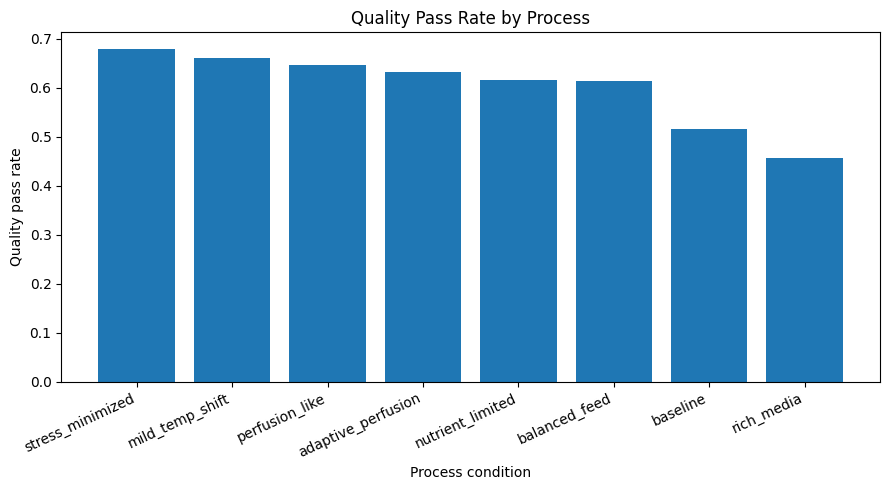

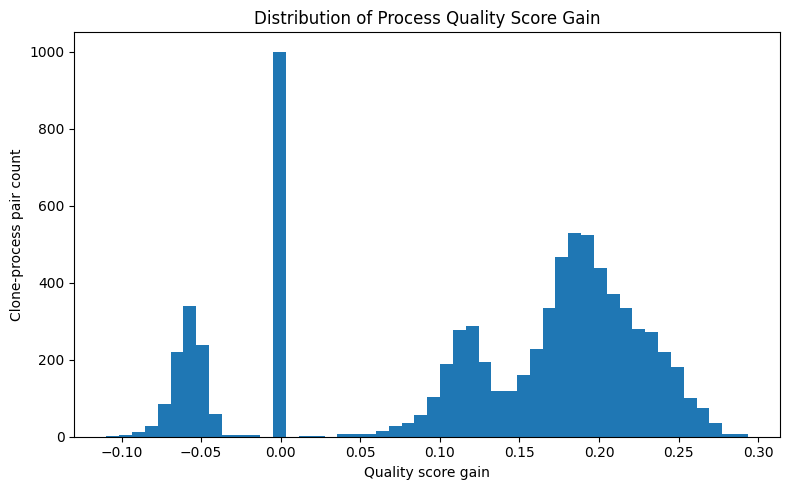

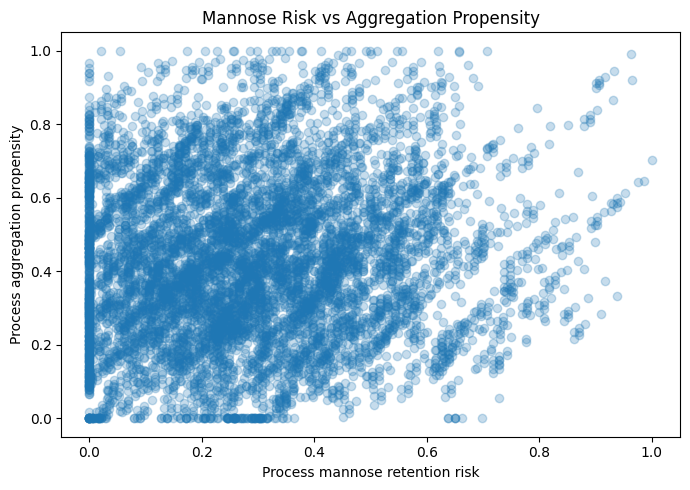

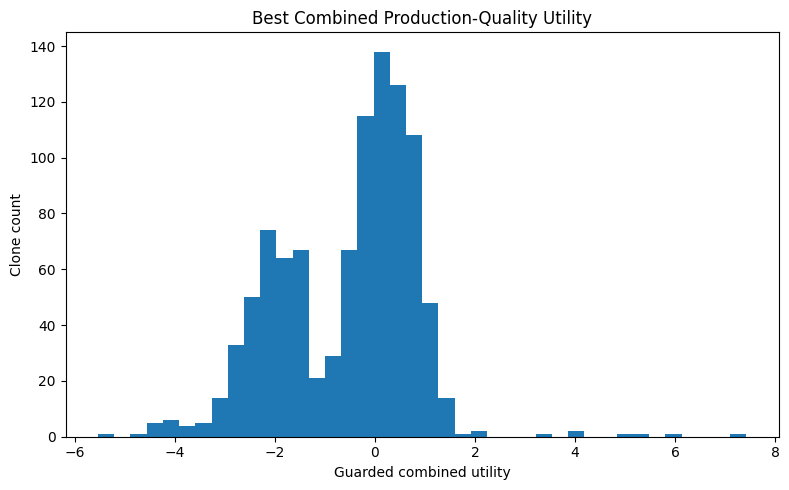

In [10]:
# --------------------------------------------------
# Section 10 — Visualization
# --------------------------------------------------

plot_df = process_quality_summary.sort_values("quality_pass_rate", ascending=False)

plt.figure(figsize=(9, 5))
plt.bar(plot_df["process_condition"], plot_df["quality_pass_rate"])
plt.title("Quality Pass Rate by Process")
plt.xlabel("Process condition")
plt.ylabel("Quality pass rate")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))
plt.hist(quality_df["quality_score_gain"], bins=50)
plt.title("Distribution of Process Quality Score Gain")
plt.xlabel("Quality score gain")
plt.ylabel("Clone-process pair count")
plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 5))
plt.scatter(
    quality_df["process_mannose_retention_risk"],
    quality_df["process_aggregation_propensity"],
    alpha=0.25,
)
plt.title("Mannose Risk vs Aggregation Propensity")
plt.xlabel("Process mannose retention risk")
plt.ylabel("Process aggregation propensity")
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))
plt.hist(best_combined["combined_quality_utility_guarded"], bins=40)
plt.title("Best Combined Production-Quality Utility")
plt.xlabel("Guarded combined utility")
plt.ylabel("Clone count")
plt.tight_layout()
plt.show()

## Section 11 — Top final quality-aware candidates

This section reports the strongest clone × process combinations after applying both production and quality logic.

These are not necessarily the highest productivity clones.

They are candidates with a favorable balance of:

- productivity
- stability
- aggregation risk
- glycosylation quality
- product quality consistency

In [11]:
# --------------------------------------------------
# Section 11 — Top final quality-aware candidates
# --------------------------------------------------

top_quality_candidates = (
    best_combined
    .sort_values("combined_quality_utility_guarded", ascending=False)
    .head(20)
    .copy()
)

display(
    top_quality_candidates[
        [
            "clone_id",
            "process_condition",
            "combined_quality_utility_guarded",
            "production_score",
            "process_quality_score",
            "quality_pass",
            "pred_late_qp",
            "pred_qp_drop",
            "pred_late_agg",
            "process_glycan_maturity",
            "process_galactosylation_level",
            "process_sialylation_capacity",
            "process_mannose_retention_risk",
            "process_aggregation_propensity",
            "process_quality_consistency",
            "pred_rescue_label",
            "pred_rescue_score",
            "is_aggressive",
            "is_super",
        ]
    ]
)

,clone_id,process_condition,combined_quality_utility_guarded,production_score,process_quality_score,quality_pass,pred_late_qp,pred_qp_drop,pred_late_agg,process_glycan_maturity,process_galactosylation_level,process_sialylation_capacity,process_mannose_retention_risk,process_aggregation_propensity,process_quality_consistency,pred_rescue_label,pred_rescue_score,is_aggressive,is_super
1446,CLONE_4625,stress_minimized,7.426625,12.063608,0.471150,True,5.537450e-06,0.357910,8.834887,1.000000,0.769200,0.646254,0.379542,0.571169,0.887545,1,1.000000,0,1
7894,CLONE_2776,stress_minimized,6.069841,9.985021,0.197072,True,5.472555e-06,0.668280,7.177550,1.000000,0.365796,0.822904,0.386953,0.238445,0.549689,0,0.583052,0,0
5846,CLONE_4878,stress_minimized,5.224530,8.468450,0.358650,True,4.417263e-06,0.452348,10.140637,1.000000,0.618129,0.457032,0.070829,0.586374,0.560952,1,0.776958,0,0
4198,CLONE_2171,stress_minimized,5.136771,8.280429,0.421283,True,5.101682e-06,0.706783,9.372360,0.879017,0.660983,0.690816,0.345871,0.310276,0.869860,1,0.629844,0,1
4974,CLONE_3254,stress_minimized,3.963699,9.846559,0.139409,False,4.310815e-06,0.310529,8.071338,0.835123,0.734077,0.901672,0.614231,0.591127,1.000000,1,0.815263,0,1
510,CLONE_3863,stress_minimized,3.940023,6.284407,0.423448,True,4.193785e-06,0.731521,8.422007,0.749178,0.984455,0.543616,0.193731,0.437778,0.592945,1,0.615623,0,0
4046,CLONE_0048,stress_minimized,3.257896,9.040122,-0.415444,False,5.334487e-06,0.618876,11.048644,0.617240,0.927803,0.469025,0.412630,0.861983,0.508748,1,0.585009,0,1
2518,CLONE_1619,stress_minimized,2.008065,6.867759,-0.281474,False,2.226262e-06,0.252291,3.094684,0.437901,0.632401,0.848192,0.158061,0.615120,0.631999,0,0.294760,0,1
190,CLONE_0643,stress_minimized,1.926609,2.869520,0.512243,True,1.779974e-06,0.533633,6.340006,0.897744,0.719203,0.968127,0.441596,0.393890,0.912056,0,0.432967,0,0
1134,CLONE_3822,stress_minimized,1.626019,2.556982,0.229576,True,3.169120e-07,0.242531,3.335838,0.869478,0.577226,0.450614,0.187240,0.457738,0.807984,0,0.149395,0,0


## Section 12 — Save outputs

This section saves Notebook09 outputs for downstream comparison.

Saved files include:

- full clone × process quality simulation table
- best quality process per clone
- best combined production-quality candidate table
- process-level quality summary

In [12]:
# --------------------------------------------------
# Section 12 — Save outputs
# --------------------------------------------------

OUTDIR = ROOT / "data" / "synthetic" / "quality"
OUTDIR.mkdir(parents=True, exist_ok=True)

quality_df_path = OUTDIR / f"notebook09_quality_simulation_{n_clones}_{scenario}.csv"
best_quality_path = OUTDIR / f"notebook09_best_quality_process_{n_clones}_{scenario}.csv"
best_combined_path = OUTDIR / f"notebook09_best_combined_quality_candidates_{n_clones}_{scenario}.csv"
summary_path = OUTDIR / f"notebook09_process_quality_summary_{n_clones}_{scenario}.csv"

quality_df.to_csv(quality_df_path, index=False)
best_quality_process.to_csv(best_quality_path, index=False)
best_combined.to_csv(best_combined_path, index=False)
process_quality_summary.to_csv(summary_path, index=False)

print("Saved:")
print(quality_df_path)
print(best_quality_path)
print(best_combined_path)
print(summary_path)

Saved:
/Users/sang/CLD_ML_PIPELINE/data/synthetic/quality/notebook09_quality_simulation_5000_legacy.csv
/Users/sang/CLD_ML_PIPELINE/data/synthetic/quality/notebook09_best_quality_process_5000_legacy.csv
/Users/sang/CLD_ML_PIPELINE/data/synthetic/quality/notebook09_best_combined_quality_candidates_5000_legacy.csv
/Users/sang/CLD_ML_PIPELINE/data/synthetic/quality/notebook09_process_quality_summary_5000_legacy.csv


# Final Interpretation — Notebook09

Notebook09 extends the CLD pipeline into product-quality-aware decision making.

The key transition is:

> clone × process optimization  
> → clone × process × product quality evaluation

This notebook shows that a clone should not be selected only because it has high predicted productivity.

A strong candidate should also maintain acceptable simulated quality attributes:

- mature glycan profile
- reasonable galactosylation
- manageable sialylation behavior
- low high-mannose risk
- low aggregation propensity
- stable product quality consistency

## What this notebook demonstrates

1. Process conditions can change product quality attributes.
2. The same process can improve one clone but create risk in another clone.
3. Productivity and quality can conflict.
4. Quality guardrails can remove otherwise attractive high-productivity candidates.
5. Final selection should consider production and product quality together.

## Current limitation

This notebook is still simulation-based.

The glycosylation and quality effects are not learned from real glycan assay data.

In a future real-data version, this notebook should be connected to:

- LC-MS glycan profiles
- HILIC-UPLC glycan maps
- charge variant data
- SEC-HPLC aggregation data
- spent media metabolomics
- process parameters
- clone-specific omics states

## Strategic meaning

Notebook09 makes the pipeline more realistic for industrial CLD.

The pipeline is now moving from:

> select the highest producer

toward:

> select the clone × process condition that balances productivity, stability, and product quality.

This is much closer to real biologics development.